In [1]:
!pip install pandas numpy scikit-learn seaborn scipy matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


# Tema 1 CC - Introducere în Machine Learning
## Job Salary Prediction Dataset

**Obiective:**
- **Clasificare multiclasă**: `vacation` ('No Vacation', 'Small', 'Medium', 'Large')
- **Regresie**: `salary`

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
SEED = 42
np.random.seed(SEED)

/home/ana_c/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
def style_table(df):
    """Bold = cel mai bun, subliniere = al doilea cel mai bun, per coloana."""
    def highlight(s):
        ascending = '↓' in s.name
        descending = '↑' in s.name
        if not ascending and not descending:
            return [''] * len(s)
        uniq = sorted(s.dropna().unique(), reverse=not ascending)
        best   = uniq[0] if len(uniq) > 0 else None
        second = uniq[1] if len(uniq) > 1 else None
        out = []
        for v in s:
            if best is not None and v == best:
                out.append('font-weight: bold')
            elif second is not None and v == second:
                out.append('text-decoration: underline')
            else:
                out.append('')
        return out
    return df.style.apply(highlight, axis=0)

---
## 1. Citirea datelor

In [4]:
train_df = pd.read_csv('CC_education_economy_train.csv')
test_df  = pd.read_csv('CC_education_economy_test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')
train_df.head(3)

Train shape: (64000, 14)
Test  shape: (16000, 14)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,total_days_worked,aggregated_score,skill_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,0,203997,4560,-0.723308,mid,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,NaN,5,116239,960,-0.481551,high,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,4,145802,1920,-1.533057,high,No Vacation


In [5]:
print('Tipuri de date (train):')
print(train_df.dtypes)
print()
print('Valori lipsă per coloană (train):')
print(train_df.isnull().sum())

Tipuri de date (train):
job_title             object
experience_years       int64
education_level       object
skills_count           int64
industry              object
company_size          object
location              object
remote_work           object
certifications         int64
salary                 int64
total_days_worked      int64
aggregated_score     float64
skill_bracket         object
vacation              object
dtype: object

Valori lipsă per coloană (train):
job_title                0
experience_years         0
education_level          0
skills_count             0
industry                 0
company_size             0
location                 0
remote_work          19153
certifications           0
salary                   0
total_days_worked        0
aggregated_score         0
skill_bracket            0
vacation                 0
dtype: int64


---
## 3.1 Explorarea Datelor (EDA)

In [6]:
TARGET_CLASS = 'vacation'
TARGET_REG   = 'salary'

# Atribute numerice
num_cols = ['experience_years', 'skills_count', 'certifications',
            'aggregated_score']  # total_days_worked eliminat (corelatie 1.0 cu experience_years)

# Atribute categoriale
cat_cols = ['job_title', 'education_level', 'industry',
            'company_size', 'location', 'remote_work', 'skill_bracket']

print('Atribute NUMERICE:', num_cols)
print('Atribute CATEGORIALE:', cat_cols)

Atribute NUMERICE: ['experience_years', 'skills_count', 'certifications', 'aggregated_score']
Atribute CATEGORIALE: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']


### 3.1.1 Analiza tipului de atribute și a plajei de valori

#### Statistici atribute numerice continue

In [7]:
desc = train_df[num_cols + [TARGET_REG]].describe().T
desc = desc[['count','mean','std','min','25%','50%','75%','max']]
desc.columns = ['Non-null', 'Medie', 'Std', 'Min', 'P25', 'P50 (median)', 'P75', 'Max']
print('Statistici atribute numerice + salary:')
desc

Statistici atribute numerice + salary:


,Non-null,Medie,Std,Min,P25,P50 (median),P75,Max
experience_years,64000.0,9.973391,6.050682,0.000000,5.000000,10.000000,15.000000,20.000000
skills_count,64000.0,11.604047,10.737497,1.000000,5.000000,10.000000,15.000000,69.000000
certifications,64000.0,2.511141,1.709811,0.000000,1.000000,3.000000,4.000000,5.000000
aggregated_score,64000.0,0.000929,0.999869,-4.796902,-0.673757,0.001059,0.678273,4.217828
salary,64000.0,145683.565844,37384.755715,31867.000000,119209.750000,143299.000000,169582.250000,333046.000000


#### Boxplot atribute numerice

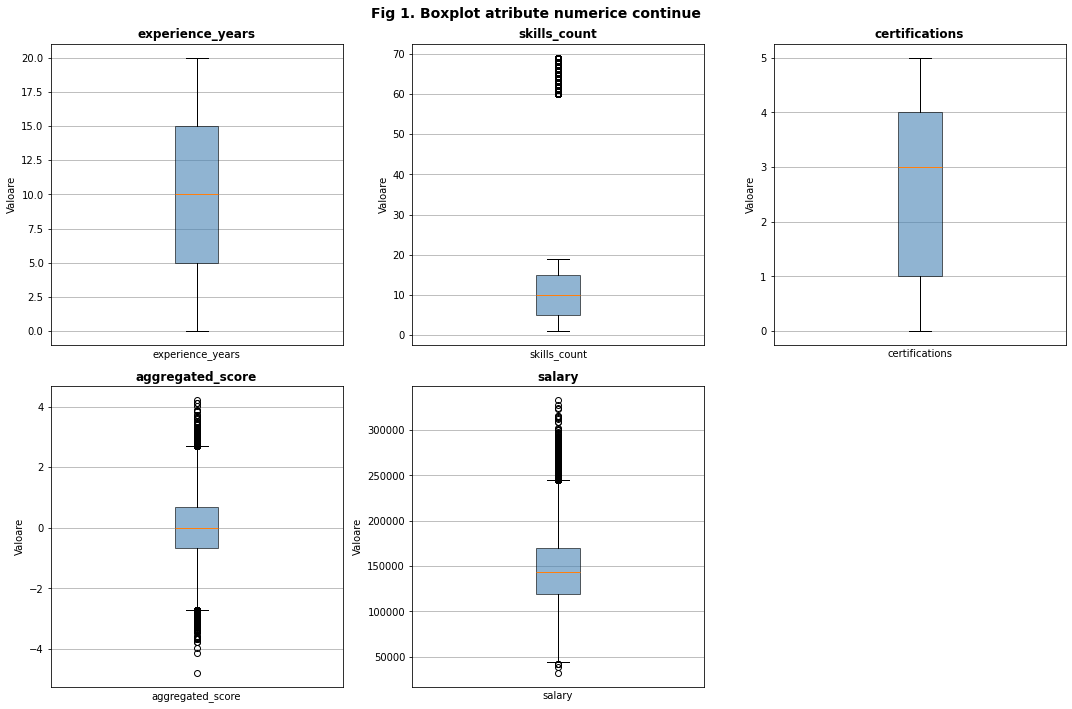

In [8]:

cols_to_plot = num_cols + [TARGET_REG]
n = len(cols_to_plot)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    data = train_df[col].dropna().values
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Valoare')
    axes[i].set_xticks([])
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Fig 1. Boxplot atribute numerice continue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()


#### Statistici atribute categoriale

In [9]:
cat_stats = []
for col in cat_cols:
    non_null = train_df[col].notna().sum()
    n_unique = train_df[col].nunique()
    top_val  = train_df[col].value_counts().idxmax() if non_null > 0 else 'N/A'
    cat_stats.append({'Atribut': col, 'Non-null': non_null,
                      'Valori unice': n_unique, 'Cea mai frecventă valoare': top_val})
pd.DataFrame(cat_stats).set_index('Atribut')

,Non-null,Valori unice,Cea mai frecventă valoare
Atribut,,,
job_title,64000,12,AI Engineer
education_level,64000,5,Bachelor
industry,64000,10,Consulting
company_size,64000,5,Large
location,64000,10,Sweden
remote_work,44847,3,Hybrid
skill_bracket,64000,3,low


#### Histograme atribute categoriale (education_level, company_size, skill_bracket)

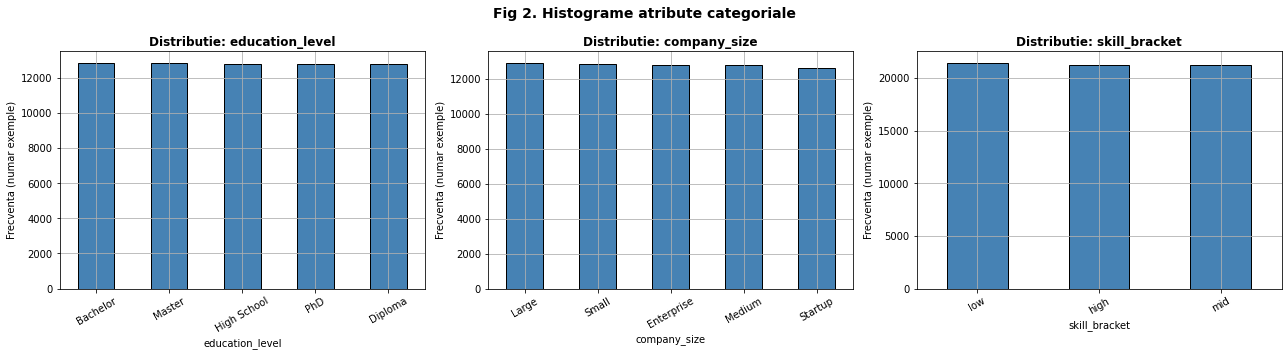

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols_to_plot = ['education_level', 'company_size', 'skill_bracket']

for ax, col in zip(axes, cols_to_plot):
    vc = train_df[col].value_counts()
    vc.plot.bar(ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distributie: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecventa (numar exemple)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Fig 2. Histograme atribute categoriale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_cat_hist.png', dpi=100, bbox_inches='tight')
plt.show()


**Observații:** `education_level` are 5 categorii (Bachelor, Master, PhD, High School, Diploma) relativ echilibrate. `company_size` include Enterprise și Startup pe lângă Small/Medium/Large. `skill_bracket` are categorii distincte (low, mid, high).

### 3.1.2 Analiza echilibrului de clase (target: vacation)

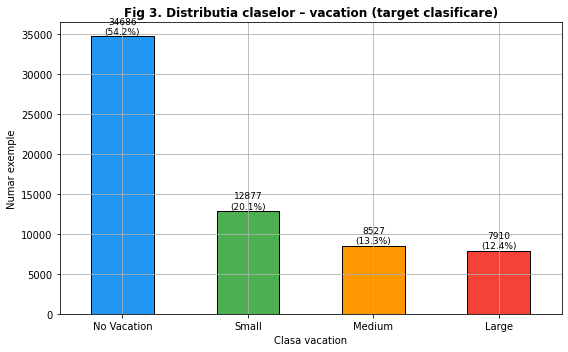

Frecvente relative:
vacation
No Vacation     54.2%
Small          20.12%
Medium         13.32%
Large          12.36%
Name: count, dtype: object


In [11]:

fig, ax = plt.subplots(figsize=(8, 5))
vc_vacation = train_df[TARGET_CLASS].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#F44336']
vc_vacation.plot.bar(ax=ax, color=colors[:len(vc_vacation)], edgecolor='black')
ax.set_title('Fig 3. Distributia claselor – vacation (target clasificare)', fontweight='bold')
ax.set_xlabel('Clasa vacation')
ax.set_ylabel('Numar exemple')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({int(p.get_height())/len(train_df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Frecvente relative:')
print((vc_vacation / len(train_df) * 100).round(2).astype(str) + '%')


### 3.1.3 Analiza corelației între atribute

#### Corelații atribute numerice (Pearson)

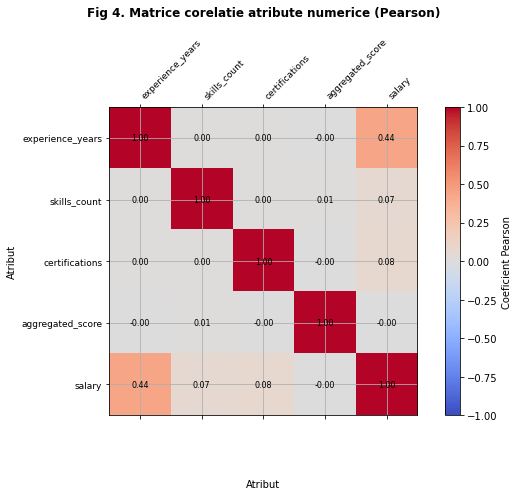

In [12]:

corr_matrix = train_df[num_cols + [TARGET_REG]].corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Coeficient Pearson')
labels = num_cols + [TARGET_REG]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Atribut', labelpad=60)
ax.set_ylabel('Atribut')
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Fig 4. Matrice corelatie atribute numerice (Pearson)', pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corr_num.png', dpi=100, bbox_inches='tight')
plt.show()


#### Corelație: atribut numeric vs clasificare (experience_years vs vacation)

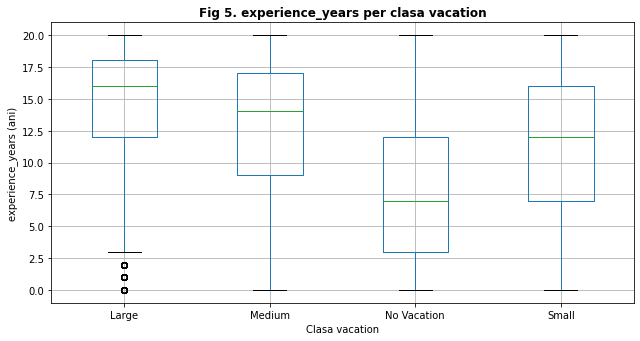

In [13]:

fig, ax = plt.subplots(figsize=(9, 5))
train_df.boxplot(column='experience_years', by=TARGET_CLASS, ax=ax)
ax.set_title('Fig 5. experience_years per clasa vacation', fontweight='bold')
ax.set_xlabel('Clasa vacation')
ax.set_ylabel('experience_years (ani)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_num_vs_class.png', dpi=100, bbox_inches='tight')
plt.show()


#### Corelație: atribut numeric vs regresie (experience_years vs salary)

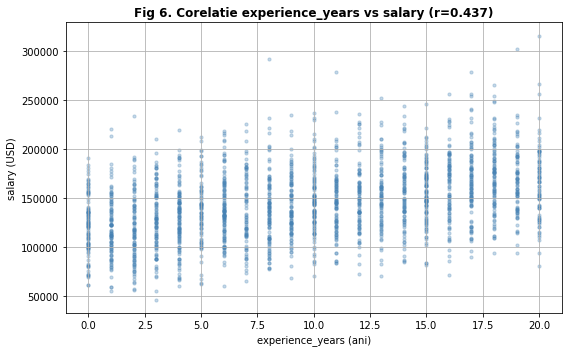

In [14]:

fig, ax = plt.subplots(figsize=(8, 5))
sample = train_df.sample(min(2000, len(train_df)), random_state=SEED)
ax.scatter(sample['experience_years'], sample[TARGET_REG], alpha=0.3, s=10, color='steelblue')
ax.set_xlabel('experience_years (ani)')
ax.set_ylabel('salary (USD)')
r = train_df[['experience_years', TARGET_REG]].corr().iloc[0,1]
ax.set_title(f'Fig 6. Corelatie experience_years vs salary (r={r:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_num_vs_reg.png', dpi=100, bbox_inches='tight')
plt.show()


#### Corelatie: atribut categorial vs clasificare (education_level vs vacation) - Chi-Patrat

In [15]:
ct = pd.crosstab(train_df['education_level'], train_df[TARGET_CLASS])
chi2, p_val, dof, _ = chi2_contingency(ct)
print(f'Chi-Pătrat education_level vs vacation:')
print(f'  chi2={chi2:.2f}, p-value={p_val:.6f}, df={dof}')
if p_val < 0.05:
    print('=> education_level și vacation SUNT corelate (rejectăm H0 de independență, p<0.05)')
else:
    print('=> education_level și vacation NU sunt corelate semnificativ (p>=0.05)')

Chi-Pătrat education_level vs vacation:
  chi2=19923.99, p-value=0.000000, df=12
=> education_level și vacation SUNT corelate (rejectăm H0 de independență, p<0.05)


In [ ]:
cat_pairs = [
    ('education_level', 'company_size'),
    ('industry',        'skill_bracket'),
    ('job_title',       'education_level'),
]

chi_rows = []
for col1, col2 in cat_pairs:
    ct = pd.crosstab(train_df[col1], train_df[col2])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_rows.append({
        'Atribut 1':  col1,
        'Atribut 2':  col2,
        'chi2':       round(chi2, 2),
        'p-value':    round(p, 8),
        'df':         dof,
        'Corelate? (p<0.05)': 'DA' if p < 0.05 else 'NU',
    })

chi_cat_df = pd.DataFrame(chi_rows).set_index('Atribut 1')
print('Tab. EDA – Corelatie Chi-Patrat intre atribute categorice')
print('(DA = corelate, posibil redundante)')
chi_cat_df


Tab. EDA – Corelatie Chi-Patrat intre atribute categorice
(DA = corelate, posibil redundante)


,Atribut 2,chi2,p-value,df,Corelate? (p<0.05)
Atribut 1,,,,,
education_level,company_size,21.99,0.143657,16,NU
industry,skill_bracket,18.46,0.425784,18,NU
job_title,education_level,17.97,0.999829,44,NU


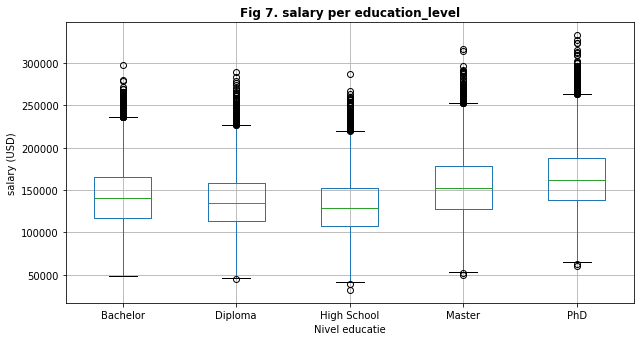

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
train_df.boxplot(column=TARGET_REG, by='education_level', ax=ax)
ax.set_title('Fig 7. salary per education_level', fontweight='bold')
ax.set_xlabel('Nivel educatie')
ax.set_ylabel('salary (USD)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_cat_vs_reg.png', dpi=100, bbox_inches='tight')
plt.show()


---
## 3.2 Preprocesarea datelor

### 3.2.1 Valori lipsă - Imputare

In [18]:
print('Valori lipsă în train:')
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
display_missing = pd.DataFrame({'Count': missing, 'Procent': missing_pct})
print(display_missing[display_missing['Count'] > 0])

Valori lipsă în train:
             Count  Procent
remote_work  19153    29.93


In [ ]:
# remote_work are ~30% valori lipsă și 3 categorii: 'Yes', 'No', 'Hybrid'
# imputam cu valoarea cea mai frecventa pentru a se pastra distributia reala

train_proc = train_df.copy()
test_proc  = test_df.copy()

# imputare remote_work cu moda calculată pe train
mode_remote = train_proc['remote_work'].mode()[0]
train_proc['remote_work'] = train_proc['remote_work'].fillna(mode_remote)
test_proc['remote_work']  = test_proc['remote_work'].fillna(mode_remote)
print(f'remote_work imputat cu moda: "{mode_remote}"')

# imputare coloane numerice cu mediana
for col in num_cols:
    if train_proc[col].isnull().any():
        med = train_proc[col].median()
        train_proc[col].fillna(med, inplace=True)
        test_proc[col].fillna(med, inplace=True)
        print(f'{col} imputat cu mediana: {med}')

print('\nValori lipsă după imputare (train):')
print(train_proc[num_cols + cat_cols].isnull().sum())

remote_work imputat cu moda: "Hybrid"

Valori lipsă după imputare (train):
experience_years    0
skills_count        0
certifications      0
aggregated_score    0
job_title           0
education_level     0
industry            0
company_size        0
location            0
remote_work         0
skill_bracket       0
dtype: int64


### 3.2.2 Valori extreme (Outlieri) - Metoda IQR

In [20]:
def remove_outliers_iqr(df, col, q1=0.25, q3=0.75):
    """Înlocuiește valorile outlier (metoda IQR) cu mediana coloanei."""
    Q1 = df[col].quantile(q1)
    Q3 = df[col].quantile(q3)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    n_outliers = mask.sum()
    if n_outliers > 0:
        median_val = df.loc[~mask, col].median()
        df.loc[mask, col] = median_val
        print(f'{col}: {n_outliers} outlieri [{lower:.2f}, {upper:.2f}] -> median={median_val:.2f}')
    else:
        print(f'{col}: 0 outlieri')
    return df

print('Tratare outlieri în setul de antrenare:')
for col in num_cols:
    train_proc = remove_outliers_iqr(train_proc, col)

Tratare outlieri în setul de antrenare:
experience_years: 0 outlieri
skills_count: 1909 outlieri [-10.00, 30.00] -> median=10.00
certifications: 0 outlieri
aggregated_score: 437 outlieri [-2.70, 2.71] -> median=0.00


### 3.2.3 Encodarea atributelor categoriale

In [ ]:
# encodare:
# - education_level (5 nivele cu ordine logică): Ordinal Encoding manual
# - company_size (5 tipuri cu ordine logică): Ordinal Encoding manual  
# - skill_bracket (low/mid/high - ordinal): LabelEncoder
# - remote_work (3 categorii fără ordine clară): LabelEncoder
# - job_title, industry, location (nominal, multe valori): One-Hot Encoding
# - vacation (target clasificare): LabelEncoder

# Education level - ordine logica crescatoare
edu_order = ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD']
edu_map = {v: i for i, v in enumerate(edu_order)}
train_proc['education_level_enc'] = train_proc['education_level'].map(edu_map).fillna(2)  # default=Bachelor
test_proc['education_level_enc']  = test_proc['education_level'].map(edu_map).fillna(2)
print('education_level map:', edu_map)

# Company size - ordine logica
size_map = {'Startup': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}
train_proc['company_size_enc'] = train_proc['company_size'].map(size_map).fillna(2)  # default=Medium
test_proc['company_size_enc']  = test_proc['company_size'].map(size_map).fillna(2)
print('company_size map:', size_map)

# Skill bracket
skill_map = {'low': 0, 'mid': 1, 'high': 2}
train_proc['skill_bracket_enc'] = train_proc['skill_bracket'].map(skill_map).fillna(1)
test_proc['skill_bracket_enc']  = test_proc['skill_bracket'].map(skill_map).fillna(1)

# Remote work - LabelEncoder
le_remote = LabelEncoder()
le_remote.fit(train_proc['remote_work']) 
train_proc['remote_work_enc'] = le_remote.transform(train_proc['remote_work'])

test_proc['remote_work_enc'] = test_proc['remote_work'].apply(
    lambda x: le_remote.transform([x])[0] if x in le_remote.classes_ else 0
)
print('remote_work classes:', list(le_remote.classes_))

# Target clasificare
le_vac = LabelEncoder()
train_proc['vacation_enc'] = le_vac.fit_transform(train_proc[TARGET_CLASS].astype(str))
print('vacation classes:', list(le_vac.classes_))
print('vacation mapping:', dict(zip(le_vac.classes_, le_vac.transform(le_vac.classes_))))

education_level map: {'High School': 0, 'Diploma': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
company_size map: {'Startup': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Enterprise': 4}


remote_work classes: ['Hybrid', 'No', 'Yes']
vacation classes: ['Large', 'Medium', 'No Vacation', 'Small']
vacation mapping: {'Large': 0, 'Medium': 1, 'No Vacation': 2, 'Small': 3}


In [22]:
# One-Hot Encoding pentru atributele nominale (job_title, industry, location)
ohe_cols = ['job_title', 'industry', 'location']
train_proc = pd.get_dummies(train_proc, columns=ohe_cols, prefix=ohe_cols)
test_proc  = pd.get_dummies(test_proc,  columns=ohe_cols, prefix=ohe_cols)

# Aliniem coloanele: test poate lipsi coloane care apar în train și viceversa
train_proc, test_proc = train_proc.align(test_proc, join='left', axis=1, fill_value=0)

print(f'Shape train după OHE: {train_proc.shape}')
print(f'Shape test  după OHE: {test_proc.shape}')

Shape train după OHE: (64000, 48)
Shape test  după OHE: (16000, 48)


### 3.2.4 Standardizarea atributelor numerice

In [ ]:
encoded_cat_cols = ['remote_work_enc', 'education_level_enc', 'company_size_enc', 'skill_bracket_enc']
ohe_feature_cols = [c for c in train_proc.columns
                    if c.startswith(('job_title_', 'industry_', 'location_'))]

feature_cols = num_cols + encoded_cat_cols + ohe_feature_cols
print(f'Total features: {len(feature_cols)}')

# crearea seturilor x si y
X = train_proc[feature_cols].copy().fillna(0)
y_class = train_proc['vacation_enc'].values
y_reg   = train_proc[TARGET_REG].values
X_test_final = test_proc[feature_cols].copy().fillna(0)

X_train, X_val, y_train_c, y_val_c, y_train_r, y_val_r = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=SEED, stratify=y_class
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

#standardizare doar pentru numerice
scaler = StandardScaler()
X_train = X_train.copy()
X_val   = X_val.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test_final = X_test_final.copy()
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

Total features: 40
Train: (51200, 40), Val: (12800, 40)
NaN în X_train: 0
NaN în X_val:   0
Standardizare completa.


---
## 3.3 Utilizarea algoritmilor de Învățare Automată

### Clasificare multiclasă: vacation

In [24]:
CLASS_NAMES = le_vac.classes_
print('Clase:', CLASS_NAMES)

# aceasta funcrie antreneaza modelul pe datele de train, face predictii pe val si calculeaza metrici de 
# evaluare pentru clasificare (accuracy, precision, recall, f1) si returneaza un dictionar
def eval_classifier(model, X_tr, y_tr, X_v, y_v, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    acc  = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_v, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_v, y_pred, average='weighted', zero_division=0)
    return {'Model': name, 'Accuracy (↑)': round(acc,4),
            'Precision (↑)': round(prec,4), 'Recall (↑)': round(rec,4), 'F1 (↑)': round(f1,4)}

clf_results = []

Clase: ['Large' 'Medium' 'No Vacation' 'Small']


#### Baseline: Arbore de decizie (max_depth=5)

In [25]:
dt_baseline = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=SEED)
res = eval_classifier(dt_baseline, X_train, y_train_c, X_val, y_val_c, 'DT baseline (depth=5)')
clf_results.append(res)
print(f"Baseline: {res}")

Baseline: {'Model': 'DT baseline (depth=5)', 'Accuracy (↑)': 0.7139, 'Precision (↑)': 0.7065, 'Recall (↑)': 0.7139, 'F1 (↑)': 0.7074}


#### Experiment 1 (Ablație): Variație max_depth în Decision Tree

In [26]:
exp1_results = []
for depth in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=SEED)
    dt.fit(X_train, y_train_c)
    y_pred = dt.predict(X_val)
    exp1_results.append({
        'max_depth': str(depth),
        'Accuracy (↑)': round(accuracy_score(y_val_c, y_pred), 4),
        'Precision (↑)': round(precision_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'Recall (↑)': round(recall_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'F1 (↑)': round(f1_score(y_val_c, y_pred, average='weighted', zero_division=0), 4)
    })

exp1_df = pd.DataFrame(exp1_results).set_index('max_depth')
print('Tab. 1 - Influența max_depth asupra performanței DT (criterion=gini)')
print(exp1_df.to_string())

Tab. 1 - Influența max_depth asupra performanței DT (criterion=gini)
           Accuracy (↑)  Precision (↑)  Recall (↑)  F1 (↑)
max_depth                                                 
3                0.6680         0.6155      0.6680  0.6325
5                0.7139         0.7065      0.7139  0.7074
10               0.7401         0.7367      0.7401  0.7382
15               0.6968         0.6981      0.6968  0.6974
20               0.6765         0.6787      0.6765  0.6776
None             0.6696         0.6731      0.6696  0.6713


**Observații:** Un `max_depth` prea mic → underfit (model prea simplu). `max_depth=None` (arbore complet) tinde spre overfit. Alegem valoarea care maximizeaza F1 pe validare.

#### Experiment 2: Variație min_samples_leaf la DT cu best max_depth

In [27]:
best_depth_str = exp1_df['F1 (↑)'].idxmax()
best_depth_val = None if best_depth_str == 'None' else int(best_depth_str)
print(f'Cel mai bun max_depth (F1 maxim pe val): {best_depth_str}')

exp2_results = []
for msl in [1, 5, 10, 20, 50]:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=best_depth_val,
                                min_samples_leaf=msl, random_state=SEED)
    dt.fit(X_train, y_train_c)
    y_pred = dt.predict(X_val)
    exp2_results.append({
        'min_samples_leaf': msl,
        'Accuracy (↑)': round(accuracy_score(y_val_c, y_pred), 4),
        'F1 (↑)': round(f1_score(y_val_c, y_pred, average='weighted', zero_division=0), 4)
    })

exp2_df = pd.DataFrame(exp2_results).set_index('min_samples_leaf')
best_msl = exp2_df['F1 (↑)'].idxmax()
print(f'\nTab. 2 - Influența min_samples_leaf (max_depth={best_depth_str})')
print(f'Best min_samples_leaf: {best_msl}')
print(exp2_df.to_string())

Cel mai bun max_depth (F1 maxim pe val): 10



Tab. 2 - Influența min_samples_leaf (max_depth=10)
Best min_samples_leaf: 50
                  Accuracy (↑)  F1 (↑)
min_samples_leaf                      
1                       0.7401  0.7382
5                       0.7424  0.7406
10                      0.7420  0.7395
20                      0.7448  0.7418
50                      0.7487  0.7439


#### Experiment 3: Random Forest

In [28]:
# Random Forest - ansamblul de arbori reduce varianța față de un singur DT
exp3_results = []
# se testeaza pe 50, 100, 200
for n_est in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=best_depth_val,
                                random_state=SEED, n_jobs=-1)
    # antrenare si evaluare
    rf.fit(X_train, y_train_c)
    y_pred = rf.predict(X_val)
    exp3_results.append({
        'n_estimators': n_est,
        'Accuracy (↑)': round(accuracy_score(y_val_c, y_pred), 4),
        'Precision (↑)': round(precision_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'Recall (↑)': round(recall_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'F1 (↑)': round(f1_score(y_val_c, y_pred, average='weighted', zero_division=0), 4)
    })

exp3_df = pd.DataFrame(exp3_results).set_index('n_estimators')
print(f'Tab. 3 - Random Forest (max_depth={best_depth_str})')
print(exp3_df.to_string())

Tab. 3 - Random Forest (max_depth=10)
              Accuracy (↑)  Precision (↑)  Recall (↑)  F1 (↑)
n_estimators                                                 
50                  0.6984         0.6524      0.6984  0.6590
100                 0.6970         0.6504      0.6970  0.6553
200                 0.6993         0.6536      0.6993  0.6600


In [ ]:
# definire cel mai bun DT și RF pe baza experimentelor
best_n_est = int(exp3_df['F1 (↑)'].idxmax())
best_rf = RandomForestClassifier(n_estimators=best_n_est, max_depth=best_depth_val,
                                 random_state=SEED, n_jobs=-1)
best_dt = DecisionTreeClassifier(criterion='gini', max_depth=best_depth_val,
                                 min_samples_leaf=best_msl, random_state=SEED)

best_dt.fit(X_train, y_train_c)
best_rf.fit(X_train, y_train_c)

print(f'best_n_est={best_n_est}, best_depth_val={best_depth_val}, best_msl={best_msl}')

# Tab. 4 – Tabel comparativ general: toți algoritmii de clasificare
all_clf_results = []
for model, name in [
    (dt_baseline, 'DT baseline (depth=5)'),
    (best_dt,     f'DT (depth={best_depth_val}, msl={best_msl})'),
    (best_rf,     f'RF (n={best_n_est}, depth={best_depth_val})'),
]:
    y_pred = model.predict(X_val)
    all_clf_results.append({
        'Model': name,
        'Accuracy (↑)': round(accuracy_score(y_val_c, y_pred), 4),
        'Precision (↑)': round(precision_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'Recall (↑)': round(recall_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
        'F1 (↑)': round(f1_score(y_val_c, y_pred, average='weighted', zero_division=0), 4),
    })

tab4_df = pd.DataFrame(all_clf_results).set_index('Model')
print('Tab. 4 – Comparație generală algoritmi de clasificare (pe setul de validare)')
print(tab4_df.to_string())

best_n_est=200, best_depth_val=10, best_msl=50
Tab. 4 – Comparație generală algoritmi de clasificare (pe setul de validare)
                       Accuracy (↑)  Precision (↑)  Recall (↑)  F1 (↑)
Model                                                                 
DT baseline (depth=5)        0.7139         0.7065      0.7139  0.7074
DT (depth=10, msl=50)        0.7487         0.7406      0.7487  0.7439
RF (n=200, depth=10)         0.6993         0.6536      0.6993  0.6600


#### Tabel comparativ algoritmi clasificare + Cel mai bun model

In [ ]:
models_perclass = [
    (dt_baseline, 'DT baseline (depth=5)'),
    (best_dt,     f'DT (depth={best_depth_val}, msl={best_msl})'),
    (best_rf,     f'RF (n={best_n_est}, depth={best_depth_val})'),
]

rows_pc = []
for model, name in models_perclass:
    y_pred = model.predict(X_val)
    prec_all = precision_score(y_val_c, y_pred, average=None, zero_division=0)
    rec_all  = recall_score(y_val_c,    y_pred, average=None, zero_division=0)
    f1_all   = f1_score(y_val_c,        y_pred, average=None, zero_division=0)
    row = {'Model': name}
    for i, cls in enumerate(CLASS_NAMES):
        row[f'P_{cls} (↑)']  = round(prec_all[i], 4)
        row[f'R_{cls} (↑)']  = round(rec_all[i],  4)
        row[f'F1_{cls} (↑)'] = round(f1_all[i],   4)
    rows_pc.append(row)

per_class_df = pd.DataFrame(rows_pc).set_index('Model')
print('Tab. 5 – Precizie / Recall / F1 per clasa pe setul de validare')
print('(bold = cel mai bun per coloana, subliniat = al doilea)')
print(per_class_df.to_string())

Tab. 5 – Precizie / Recall / F1 per clasa pe setul de validare
(bold = cel mai bun per coloana, subliniat = al doilea)
                       P_Large (↑)  R_Large (↑)  F1_Large (↑)  P_Medium (↑)  R_Medium (↑)  F1_Medium (↑)  P_No Vacation (↑)  R_No Vacation (↑)  F1_No Vacation (↑)  P_Small (↑)  R_Small (↑)  F1_Small (↑)
Model                                                                                                                                                                                                     
DT baseline (depth=5)       0.7144       0.6814        0.6975        0.4129        0.2696         0.3262             0.8671             0.8929              0.8798       0.4634       0.5460        0.5013
DT (depth=10, msl=50)       0.7742       0.7174        0.7448        0.5035        0.4584         0.4799             0.8686             0.9161              0.8917       0.5318       0.5091        0.5202
RF (n=200, depth=10)        0.7234       0.7174        0.7204        

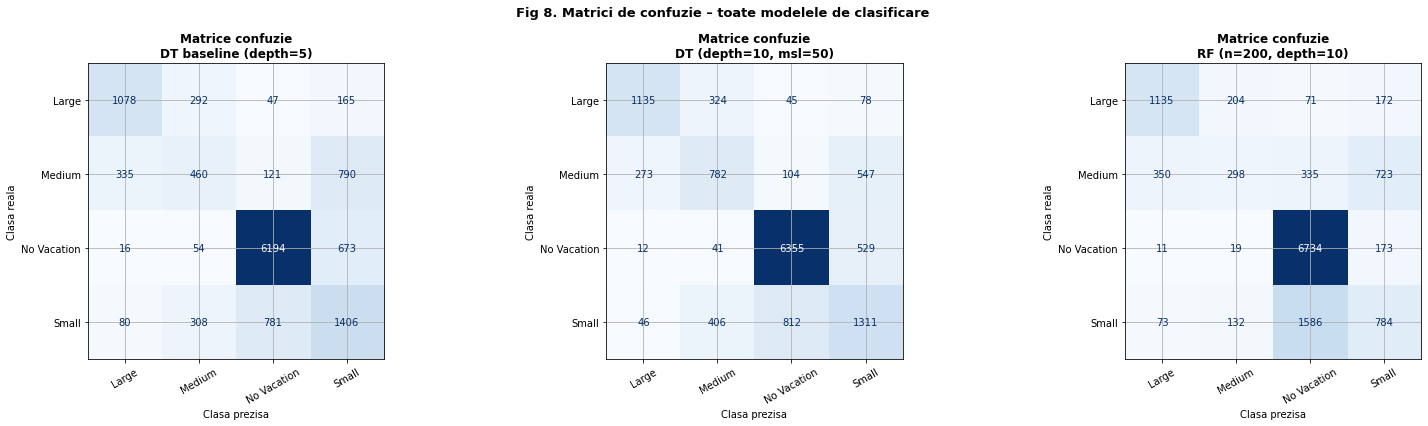

In [ ]:
best_dt.fit(X_train, y_train_c)
best_rf.fit(X_train, y_train_c)

# generarea predictiilor
y_pred_base = dt_baseline.predict(X_val)
y_pred_dt   = best_dt.predict(X_val)
y_pred_rf   = best_rf.predict(X_val)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

configs = [
    (y_pred_base, 'DT baseline (depth=5)'),
    (y_pred_dt,   f'DT (depth={best_depth_val}, msl={best_msl})'),
    (y_pred_rf,   f'RF (n={best_n_est}, depth={best_depth_val})'),
]
for ax, (y_pred, title) in zip(axes, configs):
    cm = confusion_matrix(y_val_c, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matrice confuzie\n{title}', fontweight='bold')
    ax.set_xlabel('Clasa prezisa')
    ax.set_ylabel('Clasa reala')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Fig 8. Matrici de confuzie – toate modelele de clasificare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clf_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()


#### Matrice de confuzie

**Observații:** Diagonala principală arată predicțiile corecte. Valorile mari în afara diagonalei indică clase confundate frecvent. Dacă o clasă are support mic, va fi clasificată mai eronat.

---
### Regresie: salary

In [32]:
# se defineste o functie care antreneaza modelul de regresie, face predictii pe train si val, calculeaza metrici de 
# evaluare pentru regresie (MAE, MSE, RMSE, R²) si returneaza un dictionar cu aceste valori
def eval_regressor(model, X_tr, y_tr, X_v, y_v, name='Model'):
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_v  = model.predict(X_v)
    mae_v  = mean_absolute_error(y_v, y_pred_v)
    mse_v  = mean_squared_error(y_v, y_pred_v)
    rmse_v = np.sqrt(mse_v)
    r2_v   = r2_score(y_v, y_pred_v)
    r2_tr  = r2_score(y_tr, y_pred_tr)
    print(f'{name}: MAE={mae_v:.0f}, MSE={mse_v:.0f}, RMSE={rmse_v:.0f}, R²_val={r2_v:.4f}, R²_train={r2_tr:.4f}')
    return {'Model': name, 'MAE val (↓)': round(mae_v,0), 'MSE val (↓)': round(mse_v,0),
            'RMSE val (↓)': round(rmse_v,0), 'R² val (↑)': round(r2_v,4), 'R² train (↑)': round(r2_tr,4)}

reg_results = []

#### Baseline: Regresie Liniară

In [33]:
lr = LinearRegression()
res = eval_regressor(lr, X_train, y_train_r, X_val, y_val_r, 'Linear Regression (baseline)')
reg_results.append(res)

Linear Regression (baseline): MAE=6289, MSE=66340908, RMSE=8145, R²_val=0.9522, R²_train=0.9524


#### Experiment: Variație factor de regularizare alpha - Ridge (L2)

In [ ]:
# Ridge penalizeaza suma pătratelor coeficienților (L2)
# toate atributele raman în model, dar coeficientii sunt redusi

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
train_r2_ridge, val_r2_ridge = [], []
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train_r)
    r2_tr = r2_score(y_train_r, ridge.predict(X_train))
    r2_v  = r2_score(y_val_r,   ridge.predict(X_val))
    mae_v = mean_absolute_error(y_val_r, ridge.predict(X_val))
    train_r2_ridge.append(r2_tr)
    val_r2_ridge.append(r2_v)
    ridge_results.append({'alpha': alpha, 'R² train (↑)': round(r2_tr,4),
                          'R² val (↑)': round(r2_v,4), 'MAE val (↓)': round(mae_v,0)})

ridge_df = pd.DataFrame(ridge_results).set_index('alpha')
print('Tab. 6 - Influența alpha în Ridge (regularizare L2)')
print(ridge_df.to_string())

Tab. 6 - Influența alpha în Ridge (regularizare L2)
         R² train (↑)  R² val (↑)  MAE val (↓)
alpha                                         
0.01           0.9524      0.9522       6289.0
0.10           0.9524      0.9522       6289.0
1.00           0.9524      0.9522       6289.0
10.00          0.9524      0.9522       6289.0
100.00         0.9522      0.9521       6295.0
1000.00        0.9378      0.9379       7124.0


#### Experiment: Variație alpha - Lasso (L1)

In [ ]:
# Lasso penalizeaza suma valorilor absolute ale coeficienților (L1)
# Produce selecție automată de atribute (coeficienți = 0 pentru atribute neinformative)

lasso_alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
train_r2_lasso, val_r2_lasso = [], []
lasso_results = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=3000, tol=0.01)
    lasso.fit(X_train, y_train_r)
    r2_tr = r2_score(y_train_r, lasso.predict(X_train))
    r2_v  = r2_score(y_val_r,   lasso.predict(X_val))
    mae_v = mean_absolute_error(y_val_r, lasso.predict(X_val))
    n_nz  = int(np.sum(lasso.coef_ != 0))
    train_r2_lasso.append(r2_tr)
    val_r2_lasso.append(r2_v)
    lasso_results.append({
        'alpha': alpha,
        'R² train (↑)': round(r2_tr, 4),
        'R² val (↑)':   round(r2_v,  4),
        'MAE val (↓)':   round(mae_v, 0),
        'Coef != 0':     n_nz,
    })

lasso_df = pd.DataFrame(lasso_results).set_index('alpha')
print('Tab. 7 – Influența alpha în Lasso (regularizare L1)')
print(lasso_df.to_string())

Tab. 7 – Influența alpha în Lasso (regularizare L1)
         R² train (↑)  R² val (↑)  MAE val (↓)  Coef != 0
alpha                                                    
0.01           0.9524      0.9522       6289.0         40
0.10           0.9524      0.9522       6289.0         40
1.00           0.9524      0.9522       6289.0         40
10.00          0.9524      0.9522       6289.0         35
100.00         0.9507      0.9506       6398.0         28
1000.00        0.8461      0.8461      11594.0         15


**Observații Lasso:** La valori mici de `alpha`, Lasso se comportă similar cu Regresia Liniară (toți coeficienții sunt nenuli). Pe măsură ce `alpha` creste, Lasso elimină progresiv atributele neinformative (coeficienți → 0). La `alpha=1000`, underfitting clar — R² scade semnificativ. Cel mai bun `alpha` pentru Lasso este determinat pe baza R² pe setul de validare.

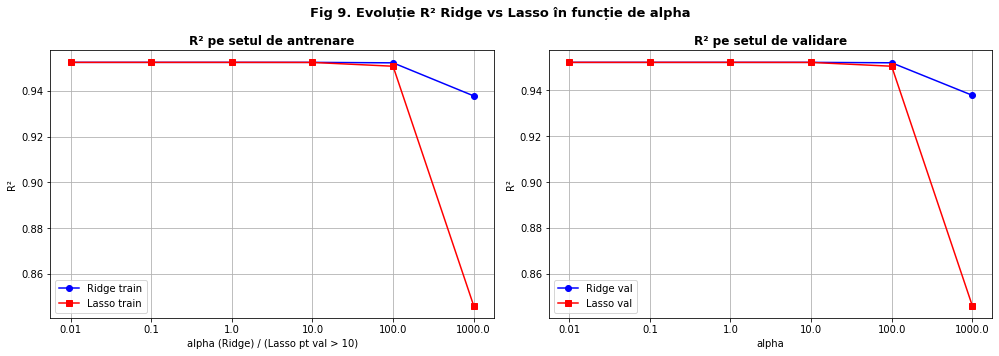

In [ ]:
# Fig 9: Evolutie R² pe train si val pentru Ridge vs Lasso
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_ridge = range(len(alphas))
x_lasso = range(len(lasso_alphas))

ax1.plot(x_ridge, train_r2_ridge, 'b-o', label='Ridge train')
ax1.plot(x_lasso, train_r2_lasso, 'r-s', label='Lasso train')
ax1.set_xticks(x_ridge)
ax1.set_xticklabels([str(a) for a in alphas])
ax1.set_xlabel('alpha (Ridge) / (Lasso pt val > 10)')
ax1.set_ylabel('R²')
ax1.set_title('R² pe setul de antrenare', fontweight='bold')
ax1.legend()

ax2.plot(x_ridge, val_r2_ridge, 'b-o', label='Ridge val')
ax2.plot(x_lasso, val_r2_lasso, 'r-s', label='Lasso val')
ax2.set_xticks(x_ridge)
ax2.set_xticklabels([str(a) for a in alphas])
ax2.set_xlabel('alpha')
ax2.set_ylabel('R²')
ax2.set_title('R² pe setul de validare', fontweight='bold')
ax2.legend()

plt.suptitle('Fig 9. Evoluție R² Ridge vs Lasso în funcție de alpha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reg_r2_curves.png', dpi=100, bbox_inches='tight')
plt.show()

Cel mai bun alpha Ridge: 1.0
Cel mai bun alpha Lasso: 1.0


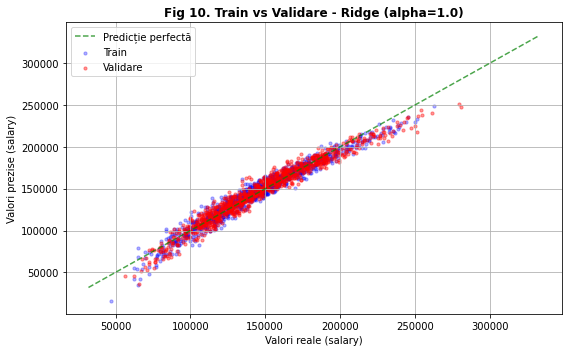

In [37]:
# Fig 10: Comportament train vs val pentru cel mai bun Ridge
best_alpha_ridge = alphas[np.argmax(val_r2_ridge)]
best_alpha_lasso = lasso_alphas[np.argmax(val_r2_lasso)]
print(f'Cel mai bun alpha Ridge: {best_alpha_ridge}')
print(f'Cel mai bun alpha Lasso: {best_alpha_lasso}')

ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train, y_train_r)

fig, ax = plt.subplots(figsize=(8, 5))
lim = [min(y_train_r.min(), y_val_r.min()), max(y_train_r.max(), y_val_r.max())]
ax.plot(lim, lim, 'g--', alpha=0.7, label='Predicție perfectă')
ax.scatter(y_train_r[:1000], ridge_best.predict(X_train)[:1000],
           alpha=0.3, s=10, label='Train', color='blue')
ax.scatter(y_val_r[:1000], ridge_best.predict(X_val)[:1000],
           alpha=0.4, s=10, label='Validare', color='red')
ax.set_xlabel('Valori reale (salary)')
ax.set_ylabel('Valori prezise (salary)')
ax.set_title(f'Fig 10. Train vs Validare - Ridge (alpha={best_alpha_ridge})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('reg_train_vs_val.png', dpi=100, bbox_inches='tight')
plt.show()

#### Tabel comparativ algoritmi de regresie

In [38]:
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=3000, tol=0.01)

res_lr    = eval_regressor(LinearRegression(), X_train, y_train_r, X_val, y_val_r,
                            'Linear Regression')
res_ridge = eval_regressor(Ridge(alpha=best_alpha_ridge), X_train, y_train_r, X_val, y_val_r,
                            f'Ridge (alpha={best_alpha_ridge})')
res_lasso = eval_regressor(lasso_best, X_train, y_train_r, X_val, y_val_r,
                            f'Lasso (alpha={best_alpha_lasso})')

reg_df = pd.DataFrame([res_lr, res_ridge, res_lasso]).set_index('Model')
print('\nTab. 8 - Comparație algoritmi de regresie pe setul de validare')
print('(↑ = mai mare e mai bun, ↓ = mai mic e mai bun)')
print(reg_df.to_string())

Linear Regression: MAE=6289, MSE=66340908, RMSE=8145, R²_val=0.9522, R²_train=0.9524
Ridge (alpha=1.0): MAE=6289, MSE=66340628, RMSE=8145, R²_val=0.9522, R²_train=0.9524


Lasso (alpha=1.0): MAE=6289, MSE=66339951, RMSE=8145, R²_val=0.9522, R²_train=0.9524

Tab. 8 - Comparație algoritmi de regresie pe setul de validare
(↑ = mai mare e mai bun, ↓ = mai mic e mai bun)
                   MAE val (↓)  MSE val (↓)  RMSE val (↓)  R² val (↑)  R² train (↑)
Model                                                                              
Linear Regression       6289.0   66340908.0        8145.0      0.9522        0.9524
Ridge (alpha=1.0)       6289.0   66340628.0        8145.0      0.9522        0.9524
Lasso (alpha=1.0)       6289.0   66339951.0        8145.0      0.9522        0.9524


---
## 4. Generarea submisiei

In [ ]:
# Antrenăm pe datele disponibile (train + val)
X_all = pd.concat([X_train, X_val], axis=0)
y_all_c = np.concatenate([y_train_c, y_val_c])
y_all_r = np.concatenate([y_train_r, y_val_r])

# Cel mai bun clasificator (DT depth=10, msl=50 are F1 mai mare decât RF)
final_clf = best_dt
final_clf.fit(X_all, y_all_c)
pred_vacation = le_vac.inverse_transform(final_clf.predict(X_test_final))

# Cel mai bun regressor
final_reg = Ridge(alpha=best_alpha_ridge)
final_reg.fit(X_all, y_all_r)
pred_salary = final_reg.predict(X_test_final)

submission = pd.DataFrame({
    'vacation': pred_vacation,
    'salary':   np.round(pred_salary, 2)
})
submission.to_csv('submission.csv', index=False)
print(f'Submisie generată: submission.csv ({submission.shape})')
print('Distribuție predicții vacation:')
print(submission['vacation'].value_counts())
print(f'\nSalary stats: mean={pred_salary.mean():.0f}, min={pred_salary.min():.0f}, max={pred_salary.max():.0f}')

Submisie generată: submission.csv ((16000, 2))
Distribuție predicții vacation:
vacation
No Vacation    9031
Small          3108
Medium         2019
Large          1842
Name: count, dtype: int64

Salary stats: mean=146557, min=2583, max=284212
